# Boundary Mass Confidence Stratification

This notebook evaluates how boundary mass and confidence stratification affect fidelity.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [29]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Synthetic Geometry Loading

We load the raw evaluation results for the various synthetic geometries (Moons, Blobs, etc.) to analyze how decision boundary mass relates to fidelity.

In [30]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.datasets import make_moons, make_circles, make_blobs, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


### Visualizing Mass vs. Gap

We plot the fraction of boundary points against the fidelity gap to demonstrate that disagreement is structurally concentrated at the boundary.

In [31]:
import matplotlib.pyplot as plt

plt.style.use("default")

In [32]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [33]:
# -----------------------------------------------------------------------------
# Load existing dataset-generalization results
# -----------------------------------------------------------------------------

RAW_RESULTS_PATH = "../dataset_generalization/dataset_generalization_raw_results.csv"
DATASET_SUMMARY_PATH = "../dataset_generalization/dataset_generalization_dataset_summary.csv"

if os.path.exists(RAW_RESULTS_PATH):
    raw_results = pd.read_csv(RAW_RESULTS_PATH)
else:
    raise FileNotFoundError(
        f"Could not find {RAW_RESULTS_PATH}. Run dataset_generalization.ipynb first "
        "or place the CSV in the same directory as this notebook."
    )

if os.path.exists(DATASET_SUMMARY_PATH):
    dataset_summary_existing = pd.read_csv(DATASET_SUMMARY_PATH)
else:
    dataset_summary_existing = None

raw_results.head()


,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,probability_mse,n_boundary_points,boundary_fraction,boundary_fidelity,boundary_task_accuracy,nonboundary_fidelity,boundary_gap,dataset,seed,surrogate,eps
0,0.914286,0.840000,0.883810,0.059355,10,0.019048,0.8,0.3,0.885437,0.083810,moons,0,logistic_regression,0.1
1,0.914286,0.840000,0.883810,0.059148,10,0.019048,0.8,0.3,0.885437,0.083810,moons,0,linear_svm_calibrated,0.1
2,0.914286,0.878095,0.929524,0.045969,10,0.019048,0.7,0.2,0.933981,0.229524,moons,0,decision_tree_depth_2,0.1
3,0.914286,0.878095,0.929524,0.036599,10,0.019048,0.7,0.2,0.933981,0.229524,moons,0,decision_tree_depth_4,0.1
4,0.914286,0.840000,0.883810,0.059026,10,0.019048,0.8,0.3,0.885437,0.083810,moons,0,small_mlp_surrogate,0.1


### Boundary Mass Correlation Analysis

We compute the fraction of points that fall strictly near the decision boundary and correlate it with the observed "boundary gap" (the disparity between global and local fidelity).

In [34]:
# -----------------------------------------------------------------------------
# Boundary mass diagnostics from existing results
# -----------------------------------------------------------------------------

boundary_mass_summary = (
    raw_results
    .groupby("dataset")
    .agg(
        n_runs=("boundary_gap", "count"),
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
        global_fidelity_mean=("global_fidelity", "mean"),
        global_fidelity_std=("global_fidelity", "std"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_fidelity_std=("boundary_fidelity", "std"),
        nonboundary_fidelity_mean=("nonboundary_fidelity", "mean"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_gap_std=("boundary_gap", "std"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
        boundary_fraction_std=("boundary_fraction", "std"),
        n_boundary_points_mean=("n_boundary_points", "mean"),
        n_boundary_points_min=("n_boundary_points", "min"),
        n_boundary_points_max=("n_boundary_points", "max"),
    )
    .sort_values("boundary_gap_mean", ascending=False)
)

boundary_mass_summary


,n_runs,teacher_task_accuracy_mean,surrogate_task_accuracy_mean,global_fidelity_mean,global_fidelity_std,boundary_fidelity_mean,boundary_fidelity_std,nonboundary_fidelity_mean,boundary_gap_mean,boundary_gap_std,boundary_fraction_mean,boundary_fraction_std,n_boundary_points_mean,n_boundary_points_min,n_boundary_points_max
dataset,,,,,,,,,,,,,,,
linear_blobs,10,0.994286,0.994248,0.997524,0.002411,0.600000,0.516398,0.997676,0.398667,0.515087,0.000381,0.000770,0.2,0,1
moons,50,0.931238,0.874857,0.904457,0.034826,0.572035,0.157388,0.911983,0.332422,0.155132,0.022286,0.006940,11.7,7,17
high_dimensional,45,0.914095,0.847048,0.864000,0.071970,0.536111,0.348257,0.866595,0.321328,0.326017,0.006476,0.004883,3.4,0,8
warped_blobs,50,0.969333,0.969143,0.990743,0.006145,0.696775,0.239589,0.994515,0.293968,0.237646,0.014095,0.006565,7.4,2,13
gaussian_overlap,50,0.755429,0.747390,0.893067,0.051560,0.685735,0.120608,0.948766,0.207331,0.081581,0.215238,0.052897,113.0,75,157
circles,50,0.850857,0.685524,0.741867,0.188368,0.535203,0.112419,0.758441,0.206664,0.139730,0.074095,0.008407,38.9,32,45
xor,50,0.846476,0.682705,0.737943,0.203502,0.592040,0.107455,0.753596,0.145903,0.155140,0.097714,0.016775,51.3,38,66
checkerboard,50,0.943238,0.544114,0.553410,0.077883,0.482051,0.142153,0.555431,0.071359,0.168272,0.034286,0.010035,18.0,8,25


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [35]:
boundary_mass_summary.to_csv("boundary_mass_summary_by_dataset.csv")
print("Saved boundary_mass_summary_by_dataset.csv")


Saved boundary_mass_summary_by_dataset.csv


In [36]:
# Surrogate-level boundary mass summary.
boundary_mass_by_surrogate = (
    raw_results
    .groupby(["dataset", "surrogate"])
    .agg(
        n_runs=("boundary_gap", "count"),
        global_fidelity_mean=("global_fidelity", "mean"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_gap_std=("boundary_gap", "std"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
        n_boundary_points_mean=("n_boundary_points", "mean"),
        n_boundary_points_min=("n_boundary_points", "min"),
    )
    .reset_index()
    .sort_values(["dataset", "boundary_gap_mean"], ascending=[True, False])
)

boundary_mass_by_surrogate


,dataset,surrogate,n_runs,global_fidelity_mean,boundary_fidelity_mean,boundary_gap_mean,boundary_gap_std,boundary_fraction_mean,n_boundary_points_mean,n_boundary_points_min
1,checkerboard,decision_tree_depth_4,10,0.662857,0.479503,0.183354,0.172964,0.034286,18.0,8
3,checkerboard,logistic_regression,10,0.510095,0.440789,0.069306,0.194847,0.034286,18.0,8
0,checkerboard,decision_tree_depth_2,10,0.541714,0.485881,0.055833,0.115174,0.034286,18.0,8
2,checkerboard,linear_svm_calibrated,10,0.523810,0.469092,0.054718,0.208544,0.034286,18.0,8
4,checkerboard,small_mlp_surrogate,10,0.528571,0.534988,-0.006417,0.091028,0.034286,18.0,8
9,circles,small_mlp_surrogate,10,0.963619,0.631434,0.332185,0.099900,0.074095,38.9,32
6,circles,decision_tree_depth_4,10,0.924571,0.600275,0.324297,0.074946,0.074095,38.9,32
5,circles,decision_tree_depth_2,10,0.746667,0.524102,0.222565,0.073392,0.074095,38.9,32
7,circles,linear_svm_calibrated,10,0.514667,0.427711,0.086955,0.079774,0.074095,38.9,32
8,circles,logistic_regression,10,0.559810,0.492493,0.067317,0.091065,0.074095,38.9,32


In [37]:
boundary_mass_by_surrogate.to_csv("boundary_mass_summary_by_dataset_surrogate.csv", index=False)
print("Saved boundary_mass_summary_by_dataset_surrogate.csv")


Saved boundary_mass_summary_by_dataset_surrogate.csv


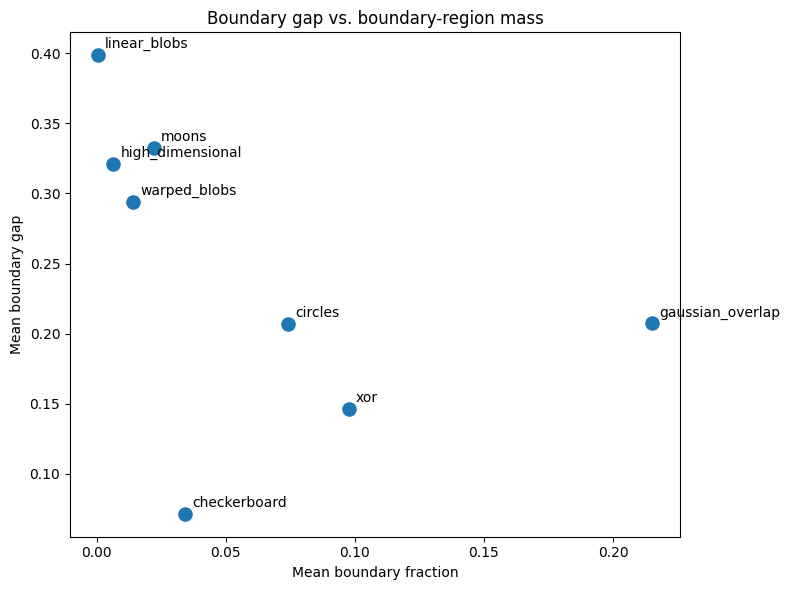

In [38]:
# -----------------------------------------------------------------------------
# Boundary mass plots
# -----------------------------------------------------------------------------

plot_df = boundary_mass_summary.reset_index().copy()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["boundary_fraction_mean"], plot_df["boundary_gap_mean"], s=90)
for _, row in plot_df.iterrows():
    ax.annotate(row["dataset"], (row["boundary_fraction_mean"], row["boundary_gap_mean"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Mean boundary fraction")
ax.set_ylabel("Mean boundary gap")
ax.set_title("Boundary gap vs. boundary-region mass")
plt.tight_layout()
plt.savefig("boundary_gap_vs_boundary_fraction.png", dpi=200)
plt.show()


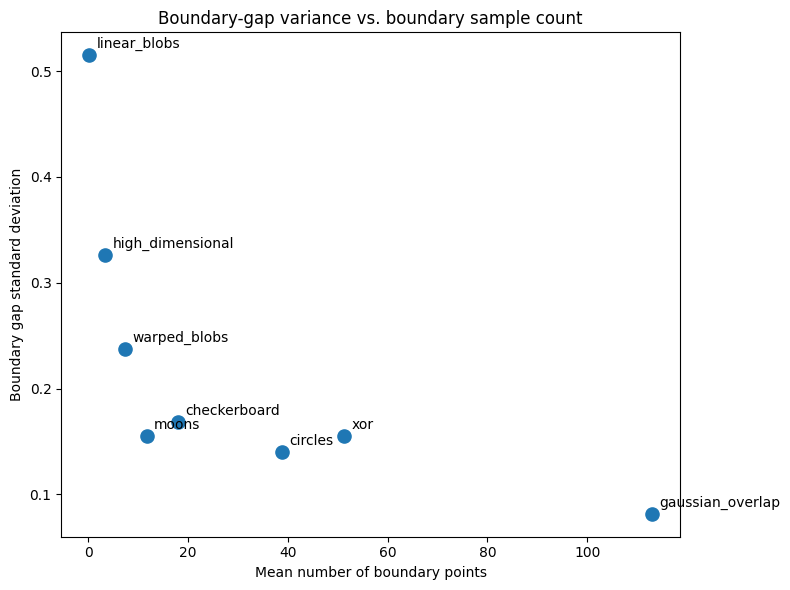

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["n_boundary_points_mean"], plot_df["boundary_gap_std"], s=90)
for _, row in plot_df.iterrows():
    ax.annotate(row["dataset"], (row["n_boundary_points_mean"], row["boundary_gap_std"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Mean number of boundary points")
ax.set_ylabel("Boundary gap standard deviation")
ax.set_title("Boundary-gap variance vs. boundary sample count")
plt.tight_layout()
plt.savefig("boundary_gap_std_vs_boundary_count.png", dpi=200)
plt.show()


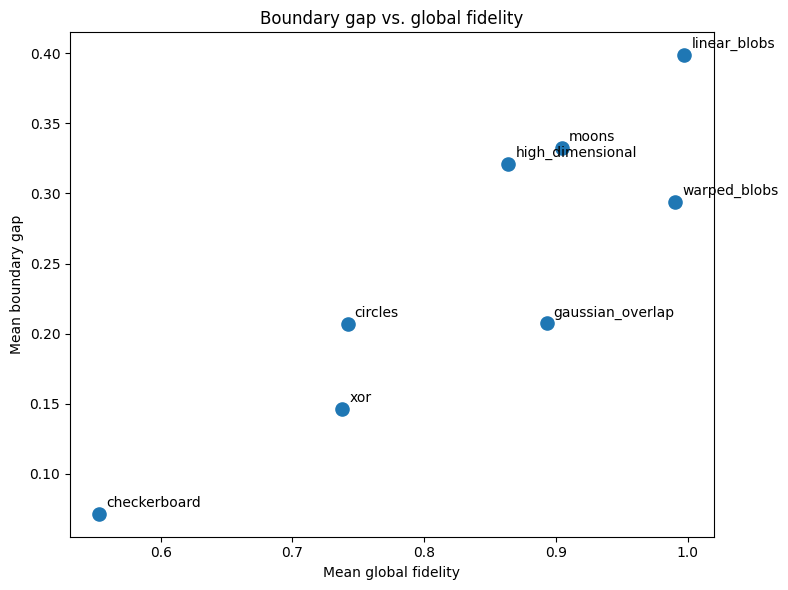

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["global_fidelity_mean"], plot_df["boundary_gap_mean"], s=90)
for _, row in plot_df.iterrows():
    ax.annotate(row["dataset"], (row["global_fidelity_mean"], row["boundary_gap_mean"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Mean global fidelity")
ax.set_ylabel("Mean boundary gap")
ax.set_title("Boundary gap vs. global fidelity")
plt.tight_layout()
plt.savefig("boundary_gap_vs_global_fidelity.png", dpi=200)
plt.show()


In [41]:
# Correlations. These are descriptive only; dataset count is small.
correlation_rows = []
for x_col in ["boundary_fraction_mean", "n_boundary_points_mean", "global_fidelity_mean", "boundary_fidelity_std"]:
    clean = plot_df[[x_col, "boundary_gap_mean"]].dropna()
    if len(clean) >= 3:
        pearson_r, pearson_p = stats.pearsonr(clean[x_col], clean["boundary_gap_mean"])
        spearman_r, spearman_p = stats.spearmanr(clean[x_col], clean["boundary_gap_mean"])
    else:
        pearson_r = pearson_p = spearman_r = spearman_p = np.nan
    correlation_rows.append({
        "x": x_col,
        "y": "boundary_gap_mean",
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "n_datasets": len(clean),
    })

correlations = pd.DataFrame(correlation_rows)
correlations


,x,y,pearson_r,pearson_p,spearman_r,spearman_p,n_datasets
0,boundary_fraction_mean,boundary_gap_mean,-0.446738,0.267140,-0.714286,0.046528,8
1,n_boundary_points_mean,boundary_gap_mean,-0.446738,0.267140,-0.714286,0.046528,8
2,global_fidelity_mean,boundary_gap_mean,0.886297,0.003369,0.880952,0.003850,8
3,boundary_fidelity_std,boundary_gap_mean,0.753708,0.030791,0.785714,0.020815,8


In [42]:
correlations.to_csv("boundary_mass_correlations.csv", index=False)
print("Saved boundary_mass_correlations.csv")


Saved boundary_mass_correlations.csv


In [43]:
# -----------------------------------------------------------------------------
# Dataset generators copied from dataset_generalization.ipynb
# -----------------------------------------------------------------------------

def make_xor(n_samples=1500, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_checkerboard(n_samples=1500, noise=0.03, random_state=42, cells=4):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-2, 2, size=(n_samples, 2))
    cell_x = np.floor((X[:, 0] + 2) / 4 * cells).astype(int)
    cell_y = np.floor((X[:, 1] + 2) / 4 * cells).astype(int)
    y = ((cell_x + cell_y) % 2).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_spiral(n_samples=1500, noise=0.18, random_state=42):
    rng = np.random.default_rng(random_state)
    n_per_class = n_samples // 2
    X_parts = []
    y_parts = []

    for cls in [0, 1]:
        r = np.linspace(0.15, 1.7, n_per_class)
        theta = np.linspace(0, 3.5 * np.pi, n_per_class) + cls * np.pi
        theta += rng.normal(scale=noise, size=n_per_class)
        x1 = r * np.cos(theta)
        x2 = r * np.sin(theta)
        X_parts.append(np.c_[x1, x2])
        y_parts.append(np.full(n_per_class, cls))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def make_warped_blobs(n_samples=1500, noise=0.08, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.2, -0.2), (1.2, 0.2)],
        cluster_std=[0.65, 0.65],
        random_state=random_state,
    )
    X = X.copy()
    X[:, 1] = X[:, 1] + 0.85 * np.sin(1.4 * X[:, 0])
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_linear_blobs(n_samples=1500, noise=0.05, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.4, 0), (1.4, 0)],
        cluster_std=[0.55, 0.55],
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_gaussian_overlap(n_samples=1500, noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)
    n0 = n_samples // 2
    n1 = n_samples - n0

    mean0 = np.array([-0.65, 0.0])
    mean1 = np.array([0.65, 0.0])
    cov0 = np.array([[1.0, 0.55], [0.55, 0.85]])
    cov1 = np.array([[1.0, -0.45], [-0.45, 0.85]])

    X0 = rng.multivariate_normal(mean0, cov0, size=n0)
    X1 = rng.multivariate_normal(mean1, cov1, size=n1)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    X += rng.normal(scale=noise, size=X.shape)

    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


def load_dataset(name, n_samples=1500, random_state=42):
    if name == "moons":
        return make_moons(n_samples=n_samples, noise=0.25, random_state=random_state)
    if name == "circles":
        return make_circles(n_samples=n_samples, noise=0.25, factor=0.45, random_state=random_state)
    if name == "xor":
        return make_xor(n_samples=n_samples, noise=0.25, random_state=random_state)
    if name == "checkerboard":
        return make_checkerboard(n_samples=n_samples, noise=0.03, random_state=random_state)
    if name == "spiral":
        return make_spiral(n_samples=n_samples, noise=0.18, random_state=random_state)
    if name == "warped_blobs":
        return make_warped_blobs(n_samples=n_samples, noise=0.08, random_state=random_state)
    if name == "linear_blobs":
        return make_linear_blobs(n_samples=n_samples, noise=0.05, random_state=random_state)
    if name == "gaussian_overlap":
        return make_gaussian_overlap(n_samples=n_samples, noise=0.0, random_state=random_state)
    if name == "high_dimensional":
        return make_classification(
            n_samples=n_samples,
            n_features=10,
            n_informative=5,
            n_redundant=2,
            n_repeated=0,
            n_classes=2,
            class_sep=1.1,
            flip_y=0.03,
            random_state=random_state,
        )
    raise ValueError(f"Unknown dataset: {name}")


### Model Training

Here we initialize and train the teacher models, followed by the respective surrogate approximation models.

In [44]:
# -----------------------------------------------------------------------------
# Models copied from dataset_generalization.ipynb
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
        model.fit(X_train, teacher_train_y)
        return model

    raise ValueError(f"Unknown surrogate: {name}")


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


In [45]:
# -----------------------------------------------------------------------------
# Confidence-bin fidelity experiment
# -----------------------------------------------------------------------------

CONFIDENCE_BINS = [0.50, 0.55, 0.60, 0.70, 0.80, 0.90, 1.00]


def confidence_bin_table(y_true, teacher_p, surrogate_p, bins=CONFIDENCE_BINS):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    teacher_conf = np.maximum(teacher_p, 1 - teacher_p)

    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        if hi == 1.00:
            mask = (teacher_conf >= lo) & (teacher_conf <= hi)
        else:
            mask = (teacher_conf >= lo) & (teacher_conf < hi)

        if mask.sum() == 0:
            fidelity = np.nan
            surrogate_acc = np.nan
            teacher_acc = np.nan
        else:
            fidelity = accuracy_score(teacher_y[mask], surrogate_y[mask])
            surrogate_acc = accuracy_score(y_true[mask], surrogate_y[mask])
            teacher_acc = accuracy_score(y_true[mask], teacher_y[mask])

        rows.append({
            "bin": f"{lo:.2f}-{hi:.2f}",
            "lo": lo,
            "hi": hi,
            "n": int(mask.sum()),
            "fraction": float(mask.mean()),
            "fidelity": fidelity,
            "teacher_task_accuracy": teacher_acc,
            "surrogate_task_accuracy": surrogate_acc,
        })

    return pd.DataFrame(rows)


def run_confidence_case(dataset_name, seed, surrogate_name, n_samples=1500):
    X, y = load_dataset(dataset_name, n_samples=n_samples, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=seed, stratify=y
    )

    teacher = train_teacher(X_train, y_train, seed=seed, epochs=500)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)
    teacher_test_p = teacher_probs(teacher, X_test)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)
    surrogate_test_p = surrogate_probs(surrogate, X_test)

    bin_df = confidence_bin_table(y_test, teacher_test_p, surrogate_test_p)
    bin_df["dataset"] = dataset_name
    bin_df["seed"] = seed
    bin_df["surrogate"] = surrogate_name
    return bin_df


In [46]:
# To keep runtime reasonable, start with two representative surrogates.
# Add more surrogates later if the pattern is useful.
confidence_datasets = [
    "moons",
    "warped_blobs",
    "gaussian_overlap",
    "linear_blobs",
    "xor",
    "checkerboard",
    "high_dimensional",
]
confidence_surrogates = [
    "logistic_regression",
    "small_mlp_surrogate",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4"
]
confidence_seeds = list(range(10))

confidence_rows = []
for dataset_name in confidence_datasets:
    print(f"\n=== Confidence bins: {dataset_name} ===")
    for seed in confidence_seeds:
        print(f"  seed {seed}")
        for surrogate_name in confidence_surrogates:
            confidence_rows.append(run_confidence_case(dataset_name, seed, surrogate_name, n_samples=1500))

confidence_results = pd.concat(confidence_rows, ignore_index=True)
confidence_results



=== Confidence bins: moons ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Confidence bins: warped_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Confidence bins: gaussian_overlap ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Confidence bins: linear_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Confidence bins: xor ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Confidence bins: checkerboard ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Confidence bins: high_dimensional ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9


,bin,lo,hi,n,fraction,fidelity,teacher_task_accuracy,surrogate_task_accuracy,dataset,seed,surrogate
0,0.50-0.55,0.50,0.55,7,0.013333,0.714286,0.142857,0.142857,moons,0,logistic_regression
1,0.55-0.60,0.55,0.60,3,0.005714,1.000000,0.666667,0.666667,moons,0,logistic_regression
2,0.60-0.70,0.60,0.70,18,0.034286,0.500000,0.555556,0.611111,moons,0,logistic_regression
3,0.70-0.80,0.70,0.80,19,0.036190,0.526316,0.684211,0.210526,moons,0,logistic_regression
4,0.80-0.90,0.80,0.90,23,0.043810,0.826087,0.652174,0.652174,moons,0,logistic_regression
...,...,...,...,...,...,...,...,...,...,...,...
2095,0.55-0.60,0.55,0.60,5,0.009524,0.800000,0.600000,0.400000,high_dimensional,9,decision_tree_depth_4
2096,0.60-0.70,0.60,0.70,7,0.013333,0.285714,0.428571,0.857143,high_dimensional,9,decision_tree_depth_4
2097,0.70-0.80,0.70,0.80,9,0.017143,0.555556,0.444444,0.666667,high_dimensional,9,decision_tree_depth_4
2098,0.80-0.90,0.80,0.90,11,0.020952,0.636364,0.545455,0.727273,high_dimensional,9,decision_tree_depth_4


In [47]:
confidence_results.to_csv("confidence_bin_fidelity_raw.csv", index=False)
print("Saved confidence_bin_fidelity_raw.csv")


Saved confidence_bin_fidelity_raw.csv


In [48]:
confidence_summary = (
    confidence_results
    .groupby(["dataset", "surrogate", "bin", "lo", "hi"])
    .agg(
        n_mean=("n", "mean"),
        n_min=("n", "min"),
        n_max=("n", "max"),
        fraction_mean=("fraction", "mean"),
        fidelity_mean=("fidelity", "mean"),
        fidelity_std=("fidelity", "std"),
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
    )
    .reset_index()
    .sort_values(["dataset", "surrogate", "lo"])
)

confidence_summary


,dataset,surrogate,bin,lo,hi,n_mean,n_min,n_max,fraction_mean,fidelity_mean,fidelity_std,teacher_task_accuracy_mean,surrogate_task_accuracy_mean
0,checkerboard,decision_tree_depth_2,0.50-0.55,0.50,0.55,8.8,2,12,0.016762,0.486288,0.107284,0.419773,0.491970
1,checkerboard,decision_tree_depth_2,0.55-0.60,0.55,0.60,9.2,4,15,0.017524,0.499101,0.175500,0.587201,0.464722
2,checkerboard,decision_tree_depth_2,0.60-0.70,0.60,0.70,17.6,12,20,0.033524,0.539750,0.126531,0.598378,0.548520
3,checkerboard,decision_tree_depth_2,0.70-0.80,0.70,0.80,23.3,18,29,0.044381,0.536300,0.133384,0.768623,0.518519
4,checkerboard,decision_tree_depth_2,0.80-0.90,0.80,0.90,29.5,22,38,0.056190,0.497290,0.095278,0.839296,0.454900
...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,xor,small_mlp_surrogate,0.55-0.60,0.55,0.60,25.7,14,32,0.048952,0.754063,0.139995,0.502133,0.558647
206,xor,small_mlp_surrogate,0.60-0.70,0.60,0.70,54.3,48,68,0.103429,0.912628,0.064308,0.630853,0.643889
207,xor,small_mlp_surrogate,0.70-0.80,0.70,0.80,53.1,44,65,0.101143,0.972022,0.039087,0.731352,0.731218
208,xor,small_mlp_surrogate,0.80-0.90,0.80,0.90,67.1,54,75,0.127810,0.996678,0.007062,0.800657,0.797335


In [49]:
confidence_summary.to_csv("confidence_bin_fidelity_summary.csv", index=False)
print("Saved confidence_bin_fidelity_summary.csv")


Saved confidence_bin_fidelity_summary.csv


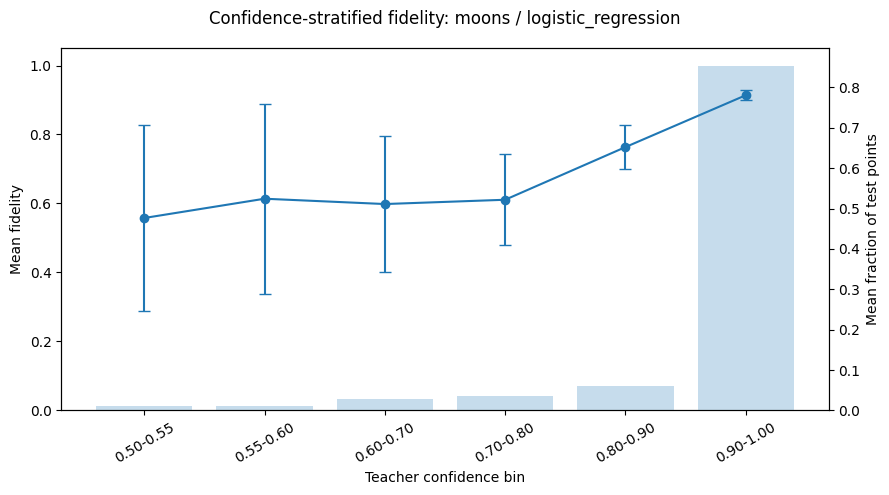

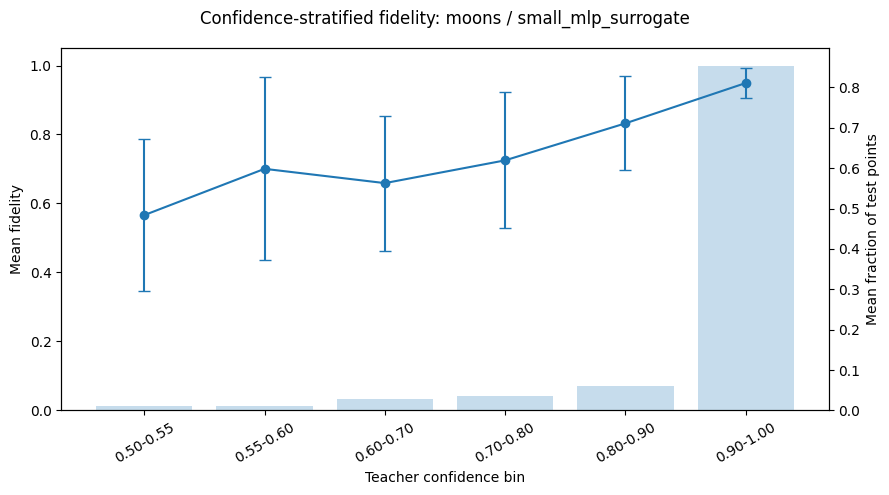

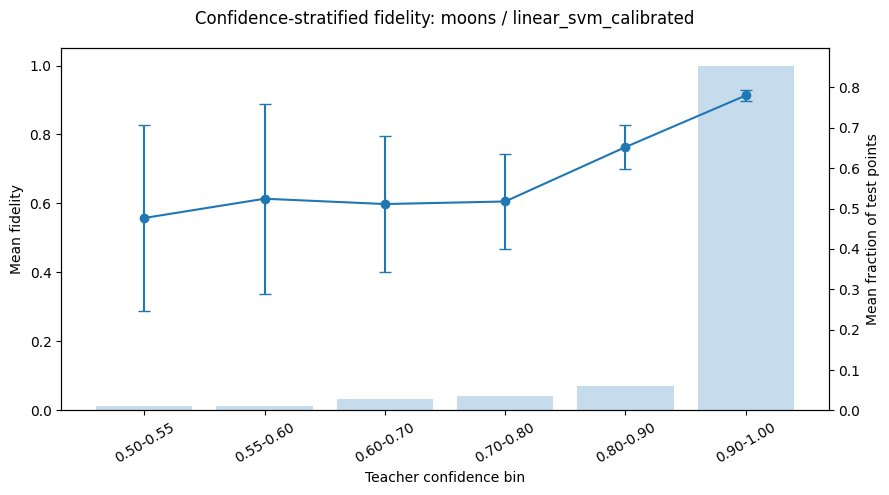

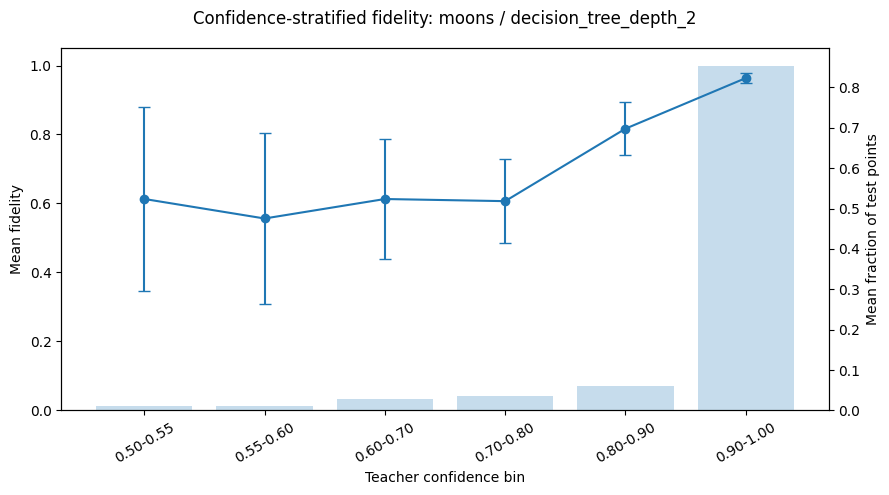

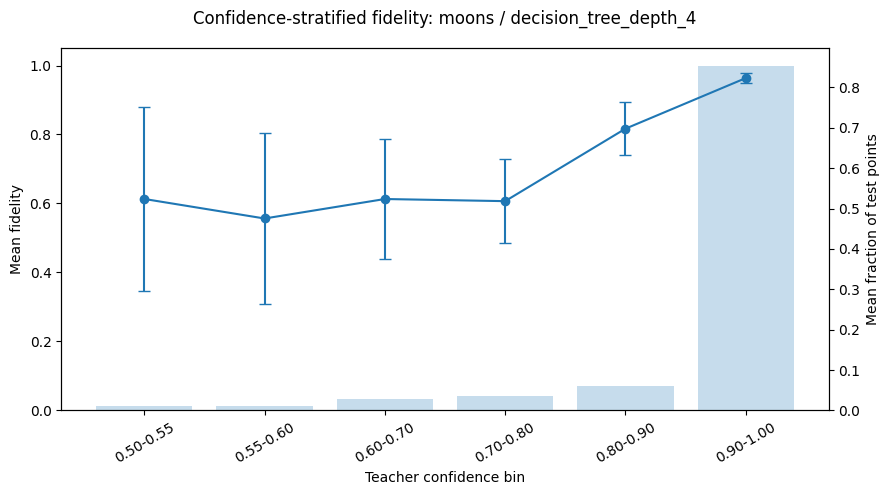

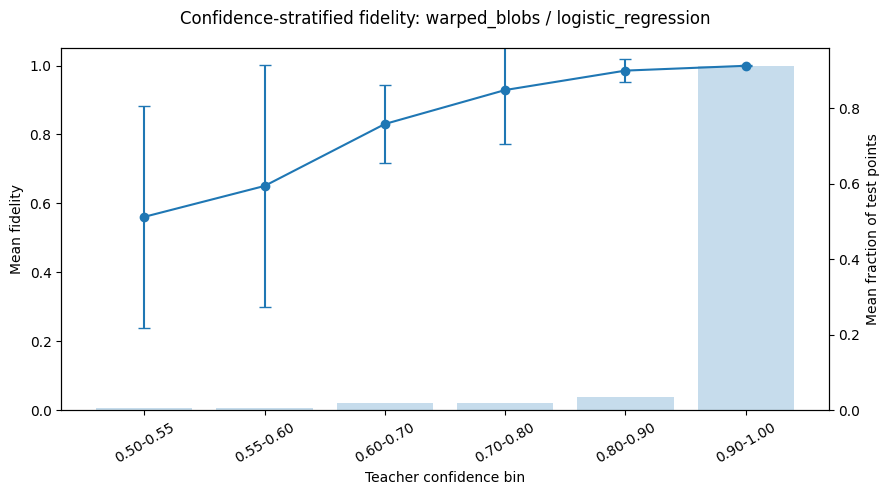

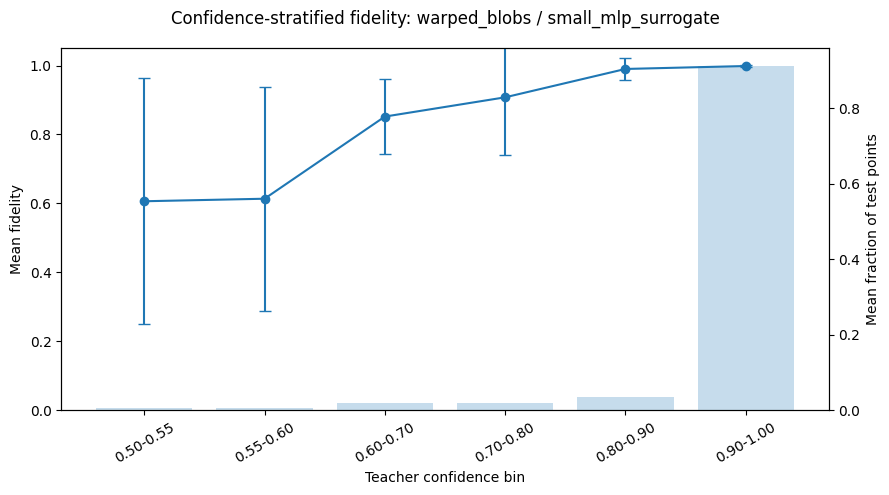

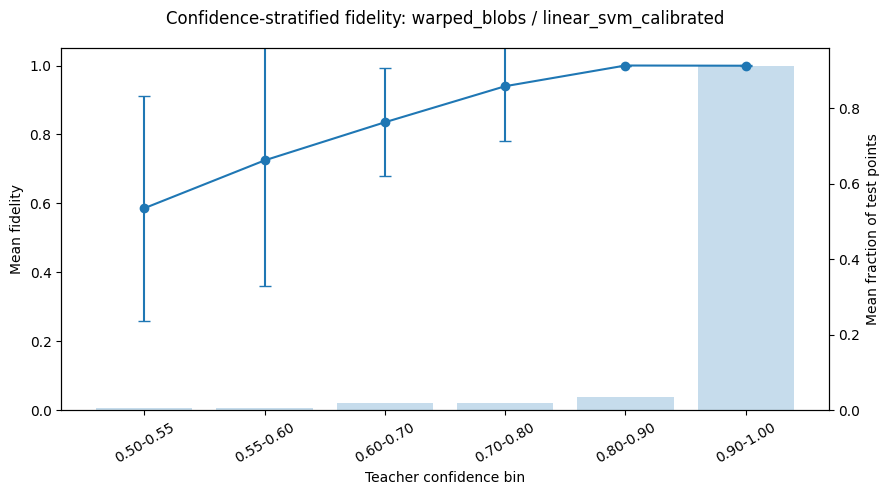

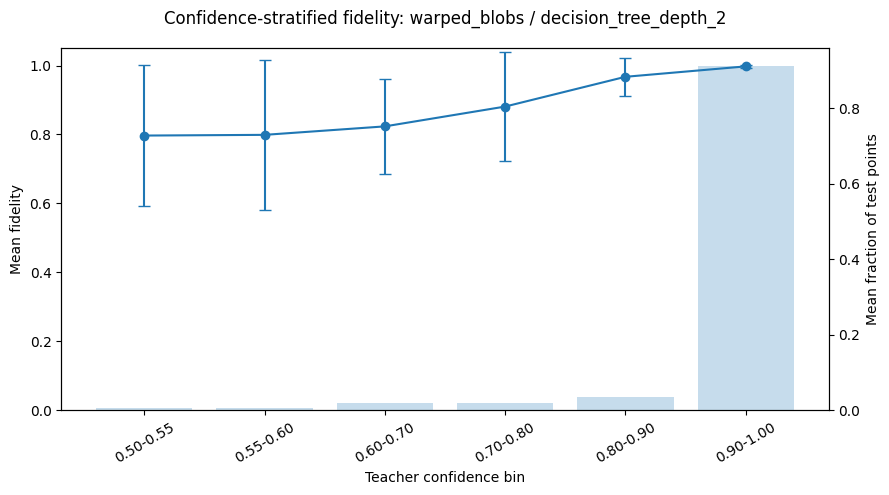

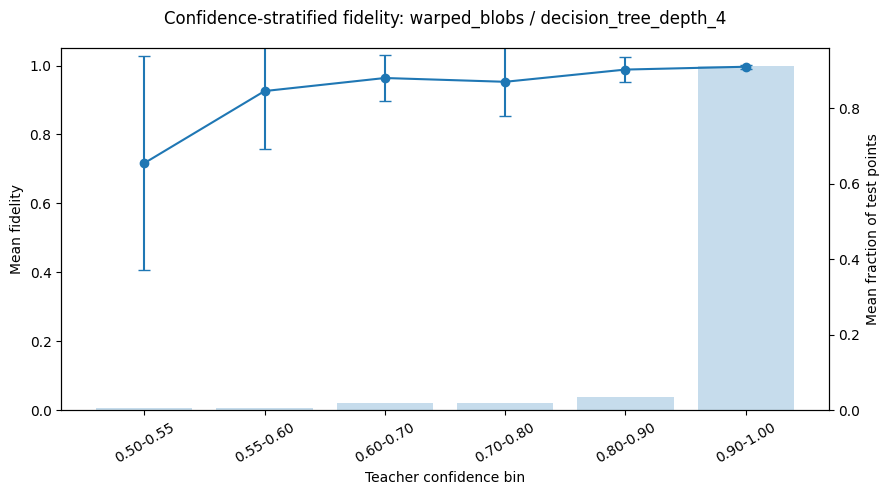

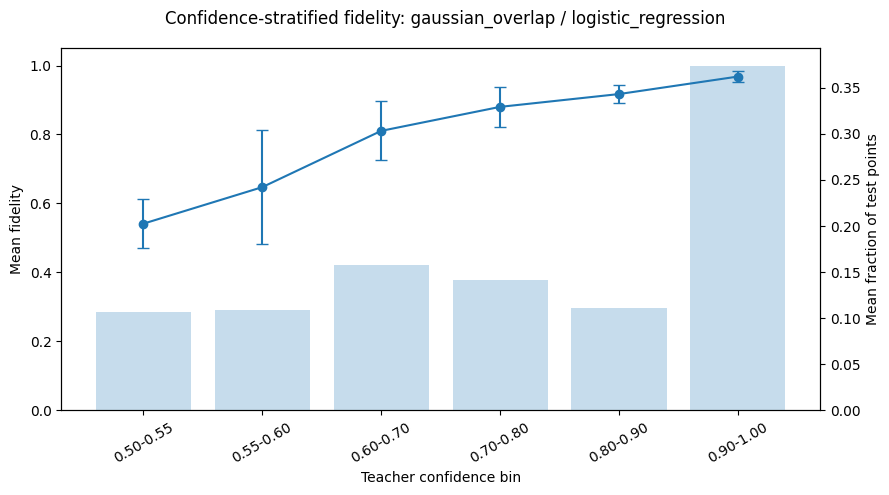

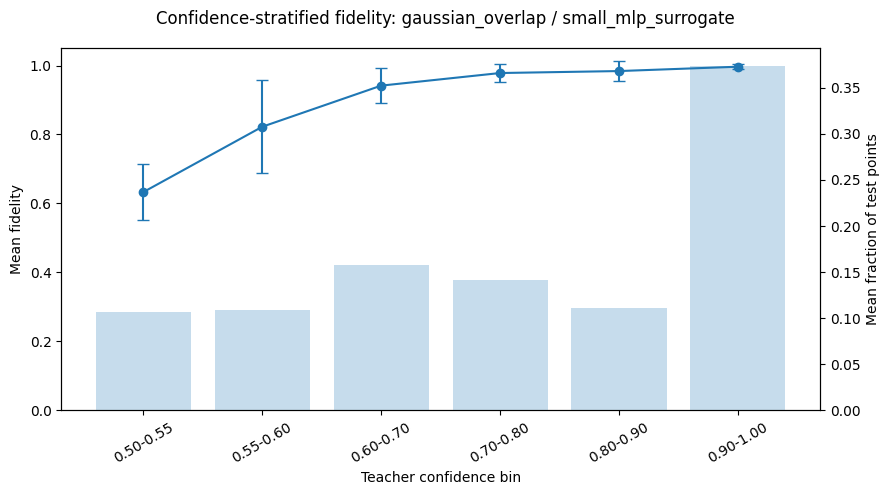

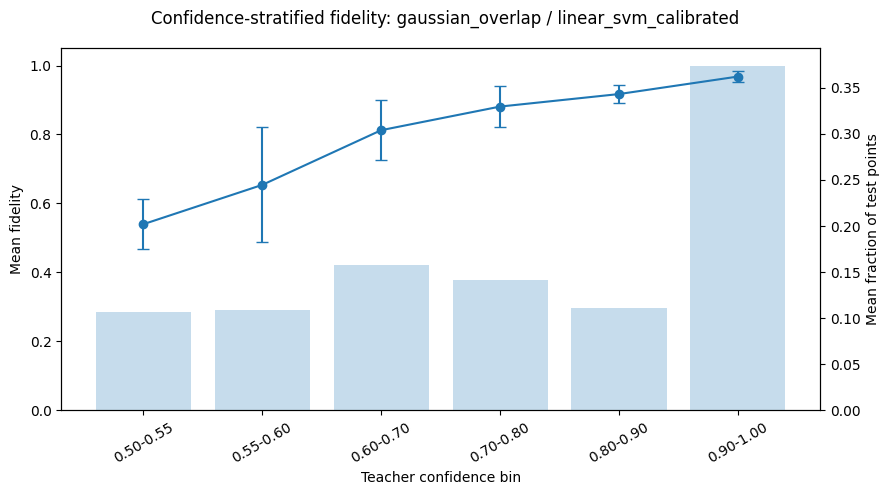

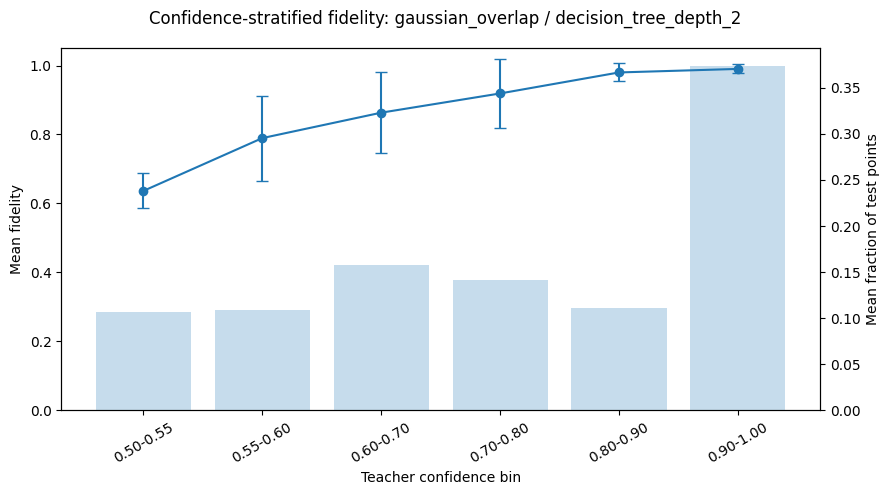

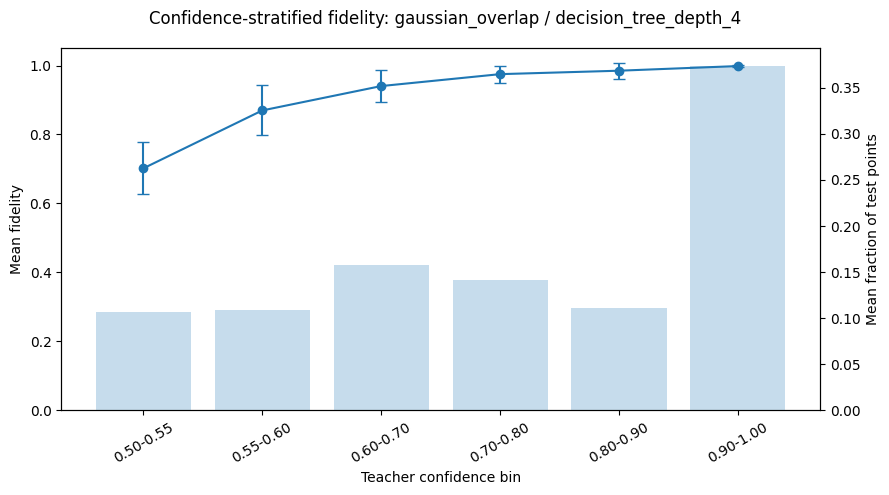

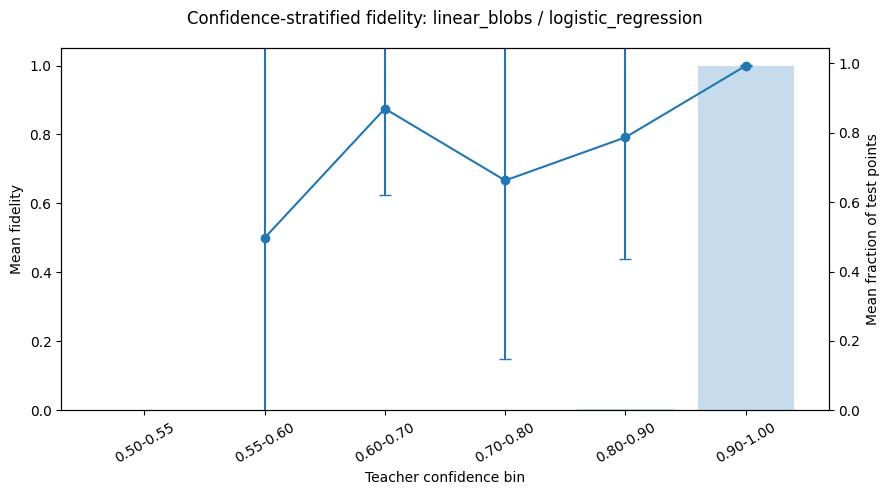

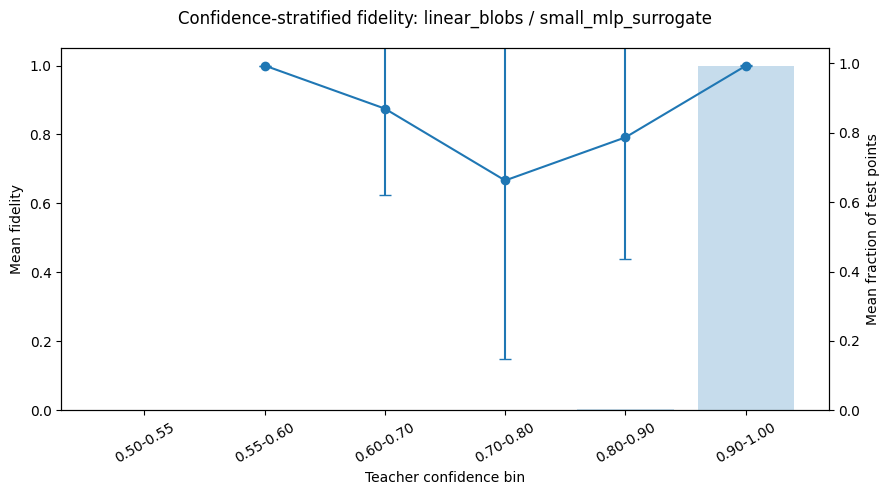

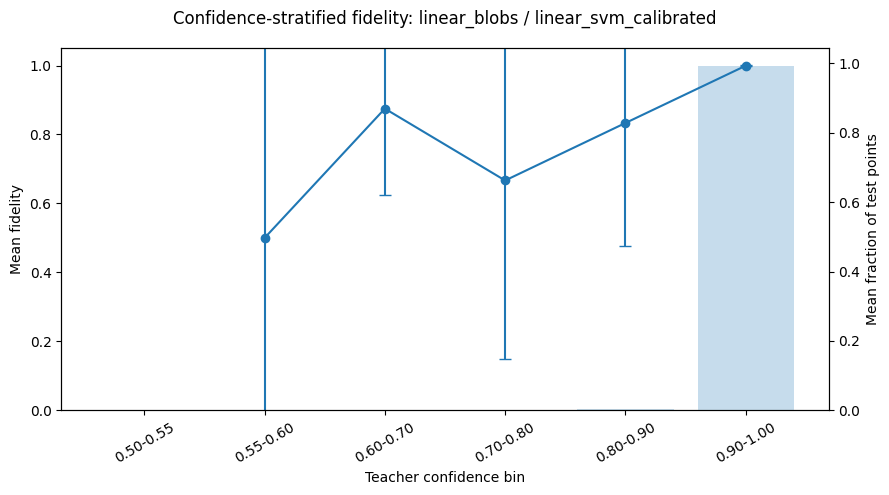

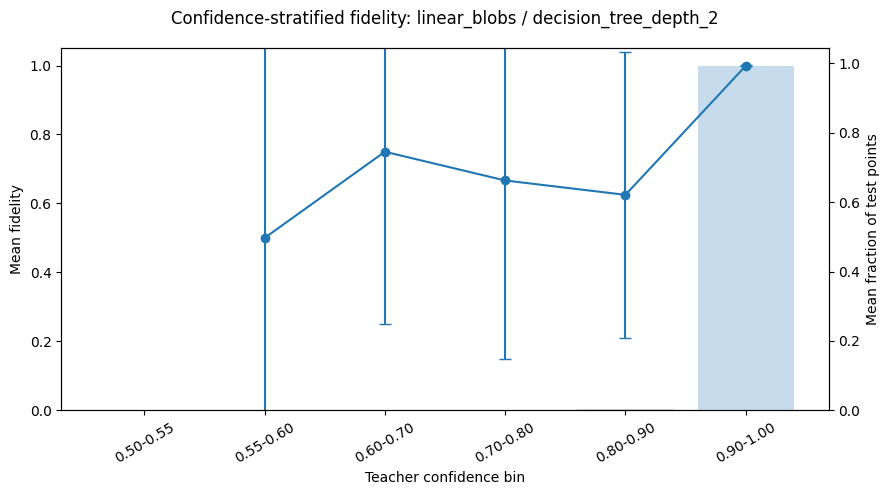

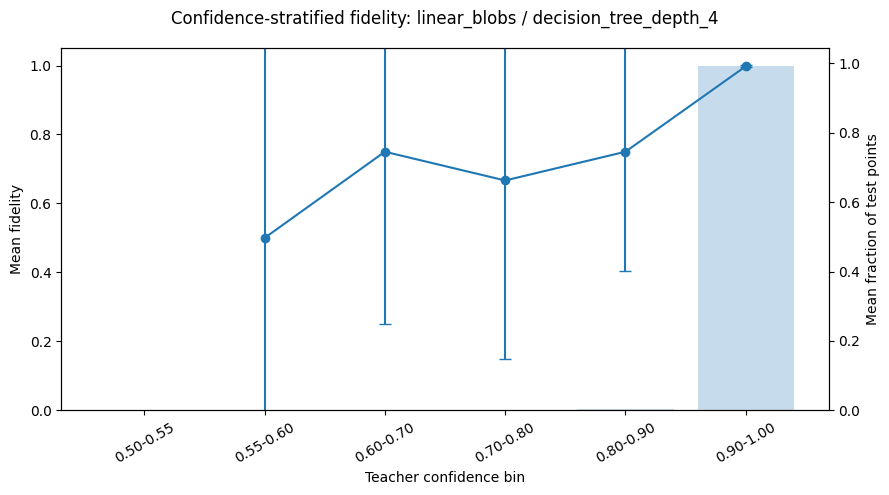

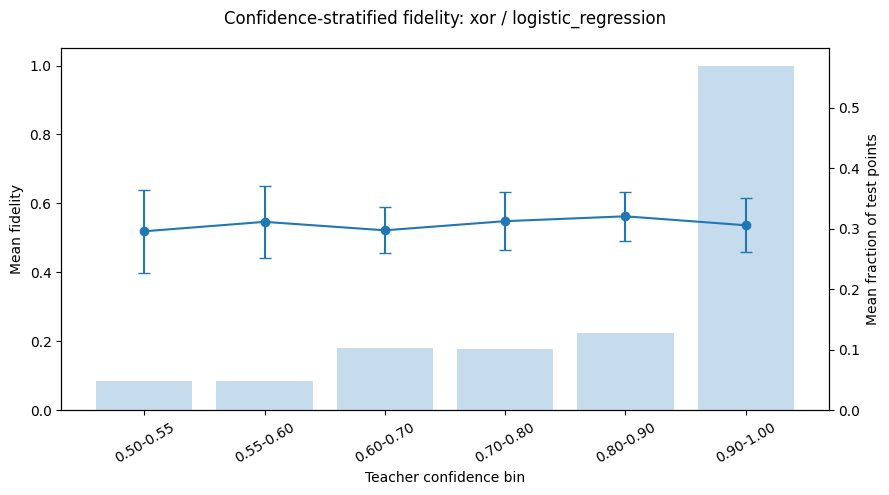

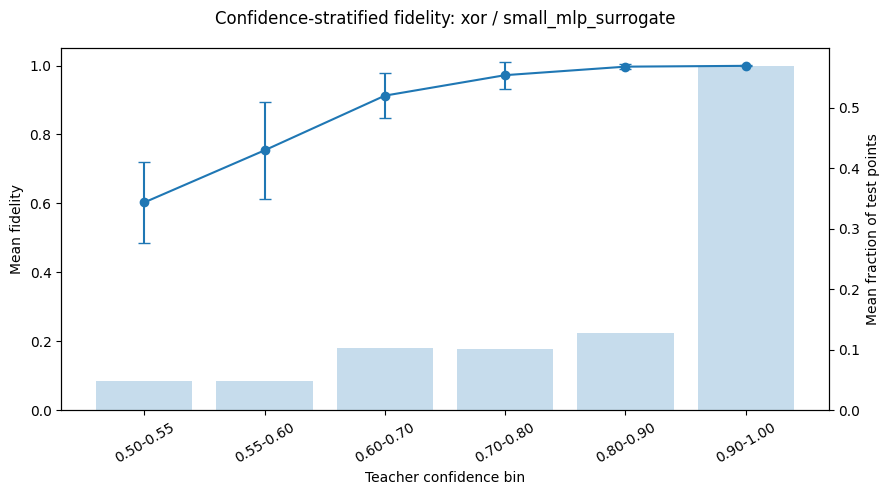

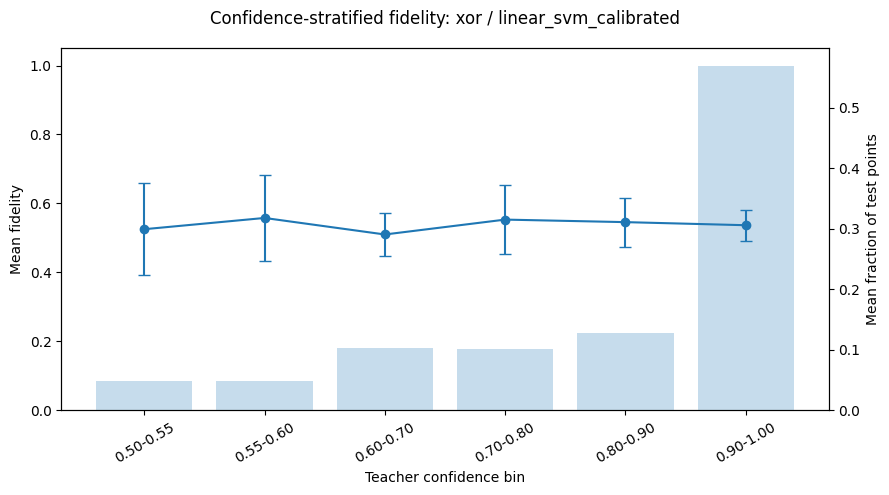

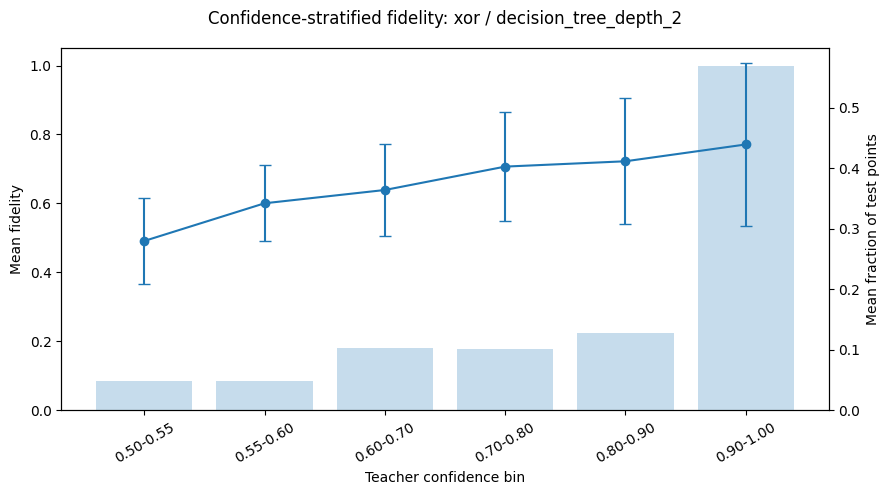

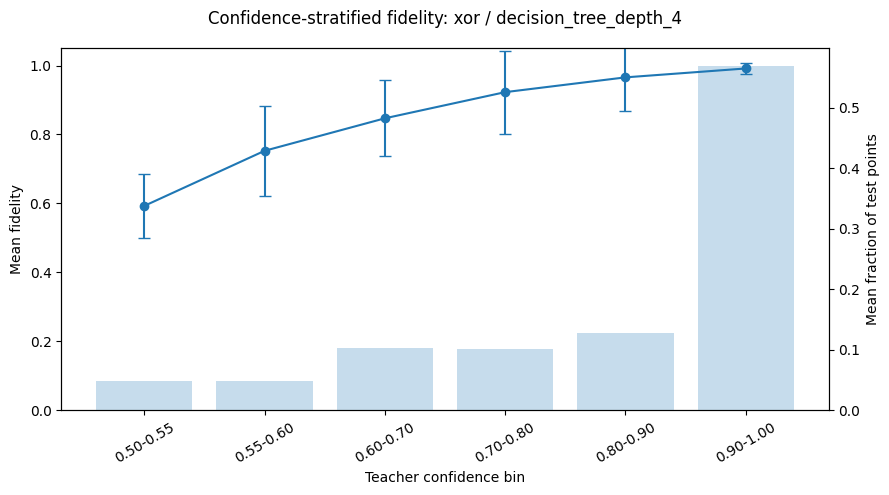

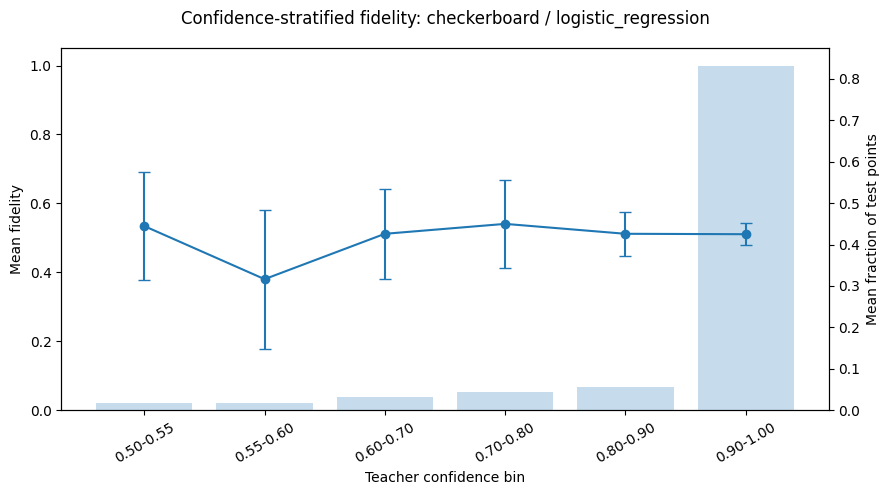

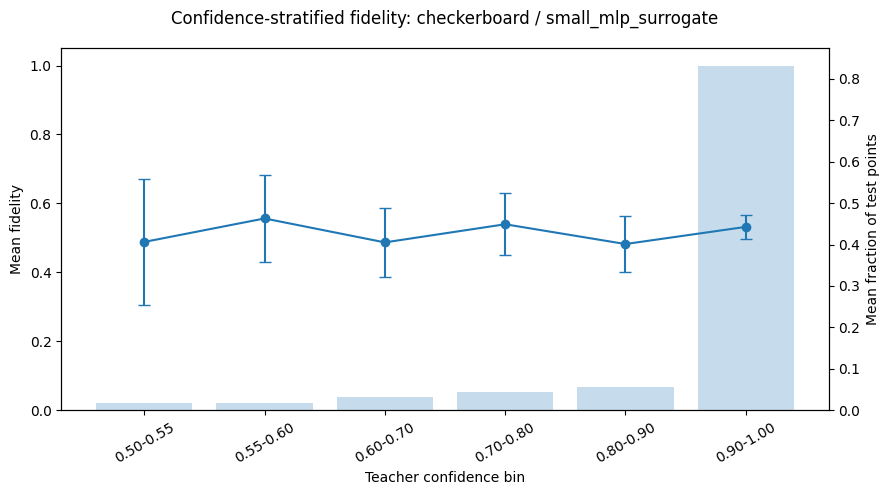

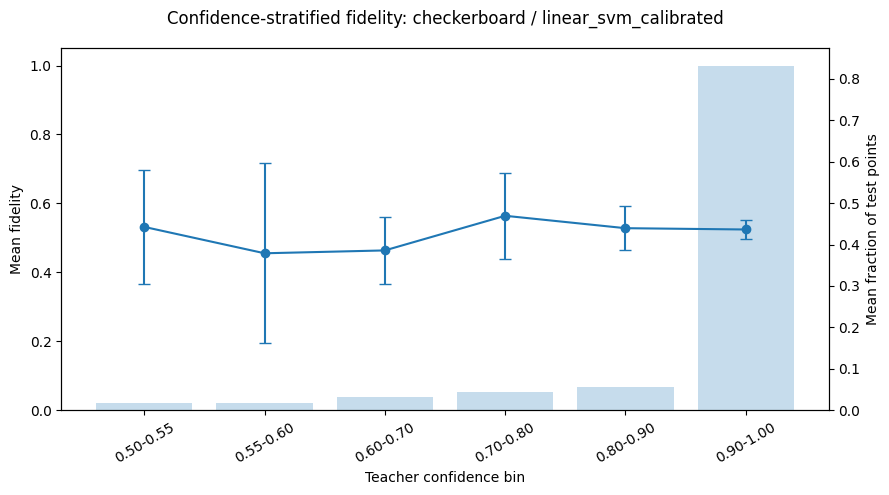

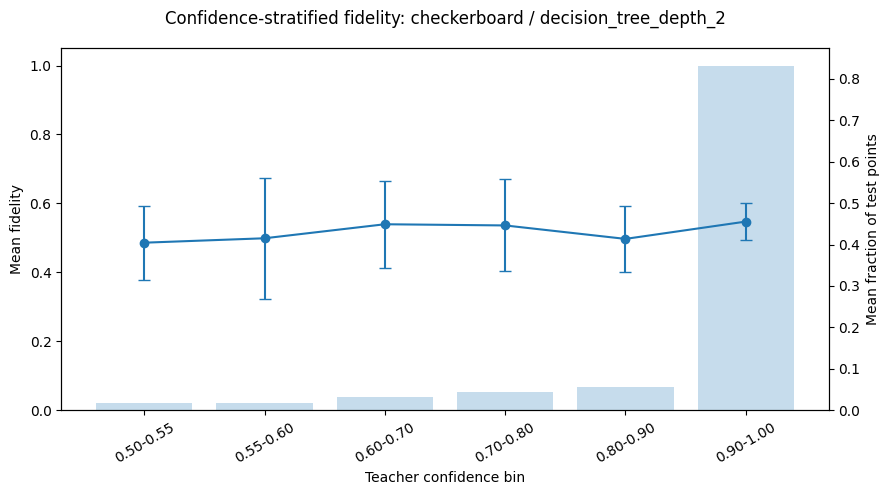

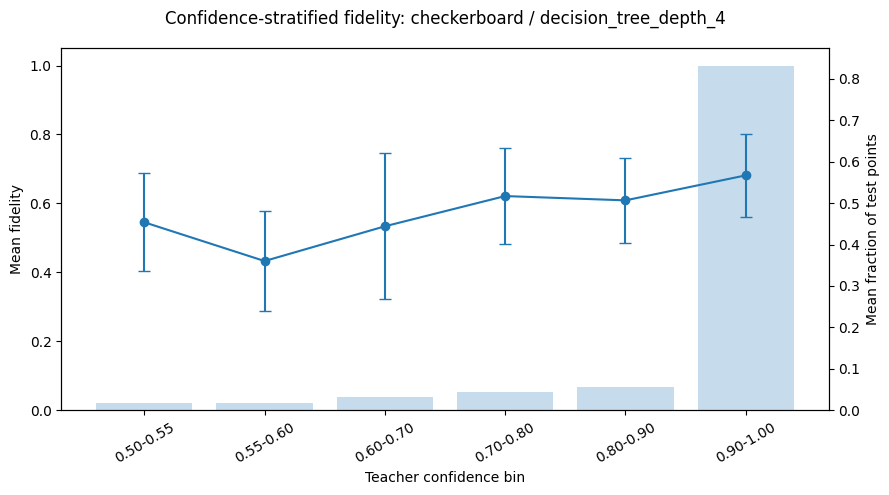

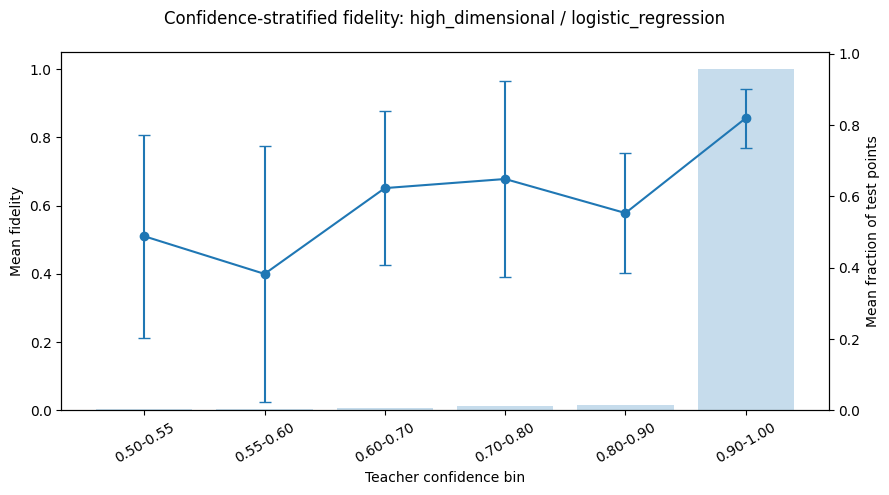

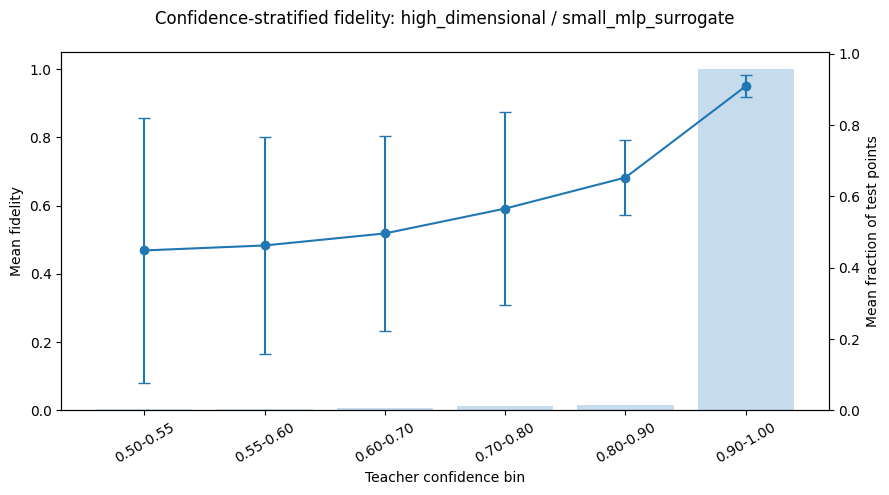

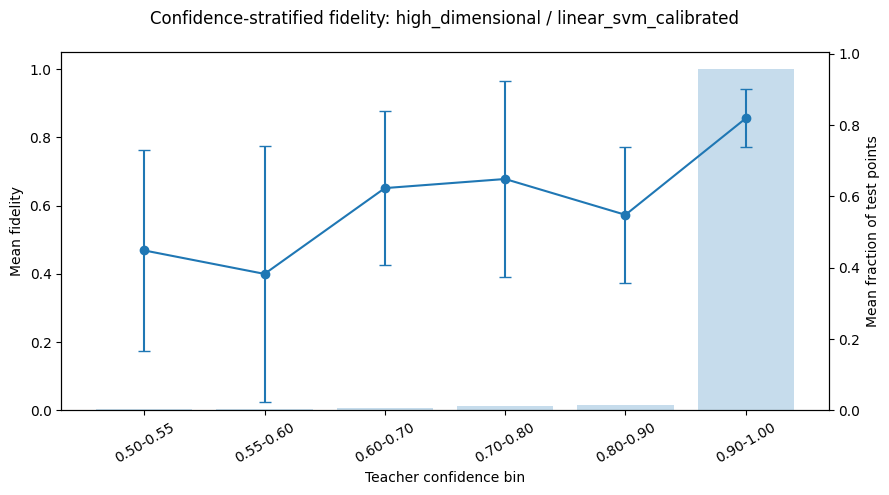

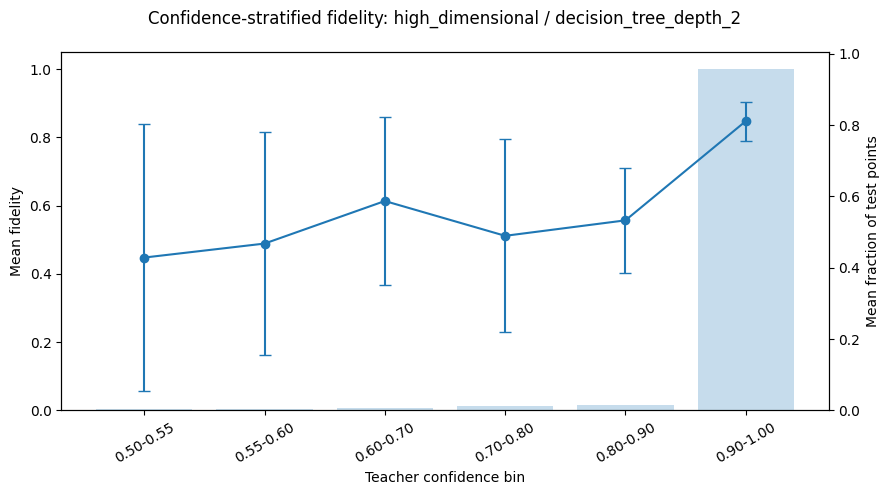

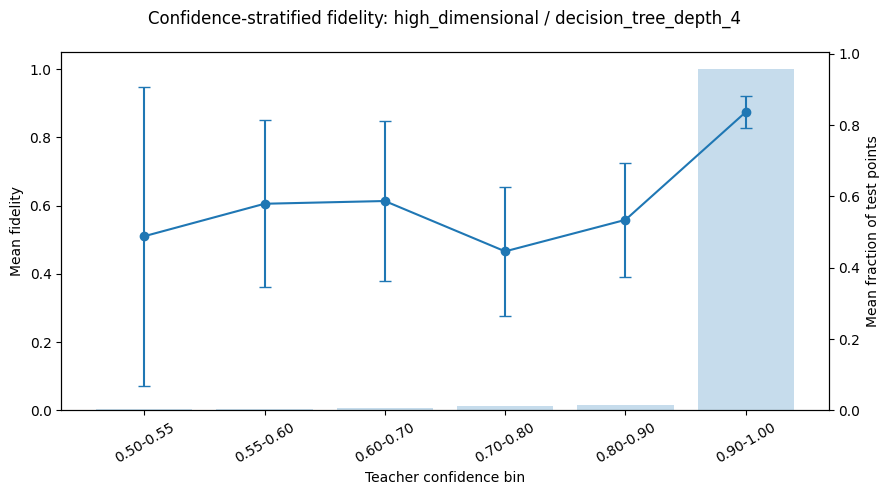

In [50]:
# -----------------------------------------------------------------------------
# Confidence-bin plots
# -----------------------------------------------------------------------------

for dataset_name in confidence_datasets:
    for surrogate_name in confidence_surrogates:
        subset = confidence_summary[
            (confidence_summary["dataset"] == dataset_name)
            & (confidence_summary["surrogate"] == surrogate_name)
        ].sort_values("lo")

        fig, ax1 = plt.subplots(figsize=(9, 5))
        ax1.errorbar(
            subset["bin"],
            subset["fidelity_mean"],
            yerr=subset["fidelity_std"],
            marker="o",
            capsize=4,
            label="Fidelity",
        )
        ax1.set_ylim(0, 1.05)
        ax1.set_xlabel("Teacher confidence bin")
        ax1.set_ylabel("Mean fidelity")
        ax1.tick_params(axis="x", rotation=30)

        ax2 = ax1.twinx()
        ax2.bar(subset["bin"], subset["fraction_mean"], alpha=0.25, label="Fraction")
        ax2.set_ylabel("Mean fraction of test points")

        fig.suptitle(f"Confidence-stratified fidelity: {dataset_name} / {surrogate_name}")
        fig.tight_layout()
        filename = f"confidence_bins_{dataset_name}_{surrogate_name}.png"
        plt.savefig(filename, dpi=200)
        plt.show()


In [51]:
# Combined confidence-bin plot averaged across datasets.
combined_confidence = (
    confidence_results
    .groupby(["surrogate", "bin", "lo", "hi"])
    .agg(
        fidelity_mean=("fidelity", "mean"),
        fidelity_std=("fidelity", "std"),
        fraction_mean=("fraction", "mean"),
    )
    .reset_index()
    .sort_values(["surrogate", "lo"])
)

combined_confidence


,surrogate,bin,lo,hi,fidelity_mean,fidelity_std,fraction_mean
0,decision_tree_depth_2,0.50-0.55,0.50,0.55,0.583147,0.236035,0.027891
1,decision_tree_depth_2,0.55-0.60,0.55,0.60,0.624203,0.245951,0.027891
2,decision_tree_depth_2,0.60-0.70,0.60,0.70,0.686261,0.219171,0.050041
3,decision_tree_depth_2,0.70-0.80,0.70,0.80,0.691127,0.260389,0.050776
4,decision_tree_depth_2,0.80-0.90,0.80,0.90,0.741257,0.246586,0.058667
5,decision_tree_depth_2,0.90-1.00,0.90,1.00,0.873748,0.181118,0.784735
6,decision_tree_depth_4,0.50-0.55,0.50,0.55,0.616993,0.247065,0.027891
7,decision_tree_depth_4,0.55-0.60,0.55,0.60,0.685706,0.260112,0.027891
8,decision_tree_depth_4,0.60-0.70,0.60,0.70,0.751775,0.246836,0.050041
9,decision_tree_depth_4,0.70-0.80,0.70,0.80,0.749201,0.266824,0.050776


In [52]:
combined_confidence.to_csv("confidence_bin_fidelity_combined_summary.csv", index=False)
print("Saved confidence_bin_fidelity_combined_summary.csv")


Saved confidence_bin_fidelity_combined_summary.csv


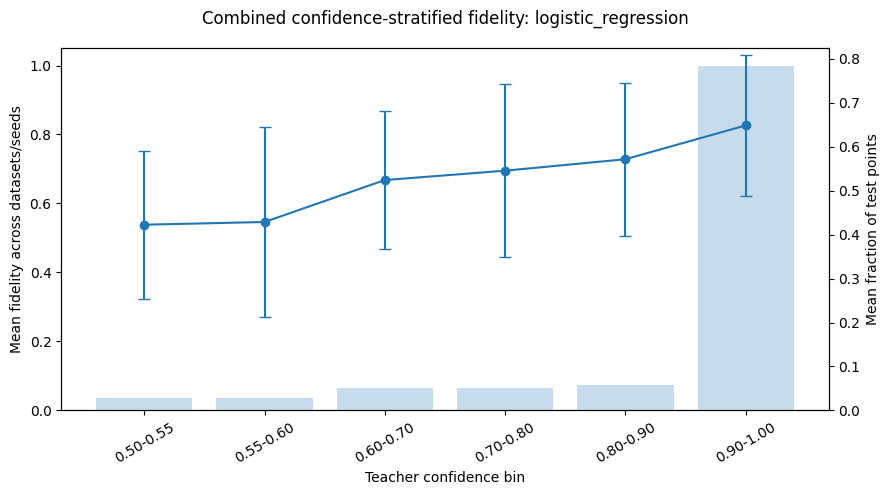

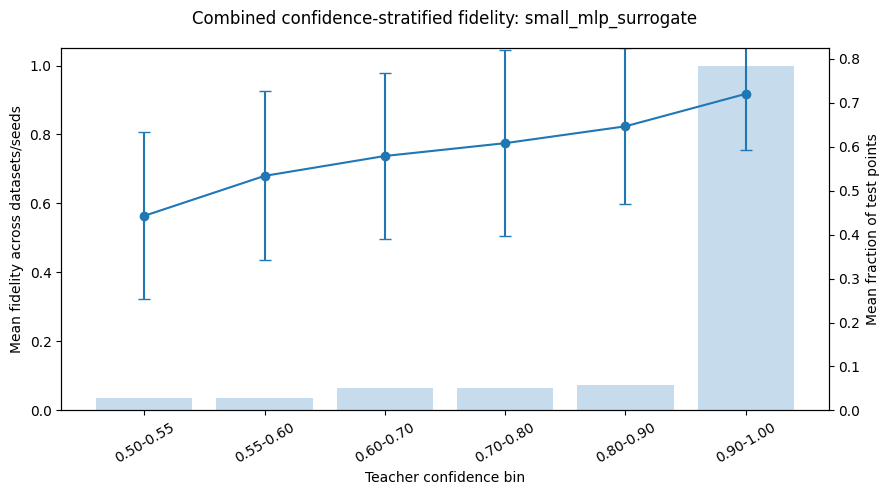

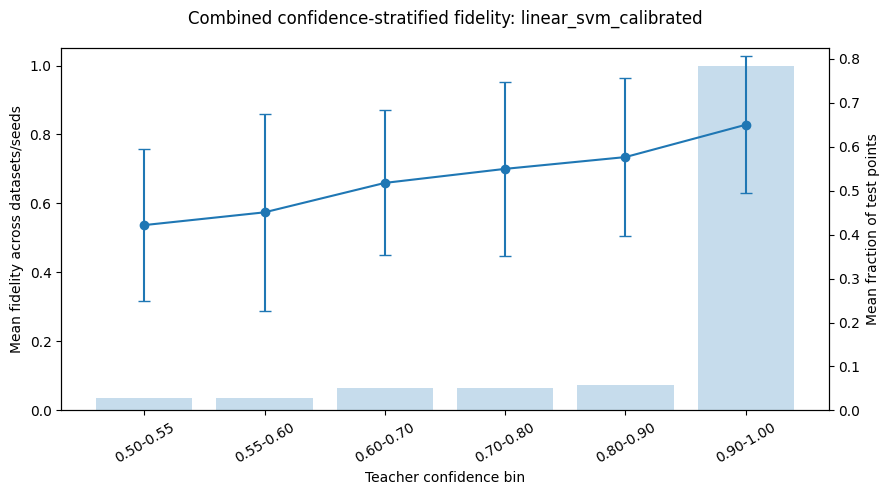

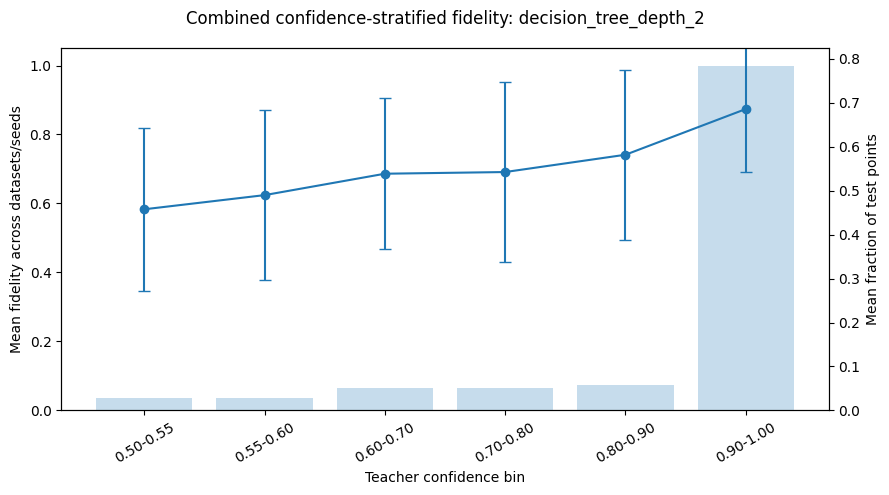

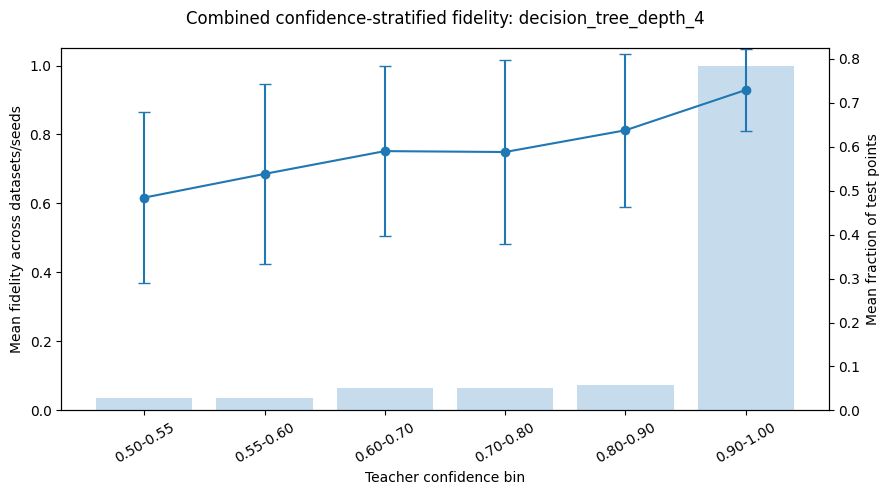

In [53]:
for surrogate_name in confidence_surrogates:
    subset = combined_confidence[combined_confidence["surrogate"] == surrogate_name]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.errorbar(
        subset["bin"],
        subset["fidelity_mean"],
        yerr=subset["fidelity_std"],
        marker="o",
        capsize=4,
        label="Fidelity",
    )
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel("Teacher confidence bin")
    ax1.set_ylabel("Mean fidelity across datasets/seeds")
    ax1.tick_params(axis="x", rotation=30)

    ax2 = ax1.twinx()
    ax2.bar(subset["bin"], subset["fraction_mean"], alpha=0.25, label="Fraction")
    ax2.set_ylabel("Mean fraction of test points")

    fig.suptitle(f"Combined confidence-stratified fidelity: {surrogate_name}")
    fig.tight_layout()
    filename = f"confidence_bins_combined_{surrogate_name}.png"
    plt.savefig(filename, dpi=200)
    plt.show()


In [54]:
# -----------------------------------------------------------------------------
# Interpretation helper table
# -----------------------------------------------------------------------------

# Low-confidence mass and fidelity by dataset/surrogate.
low_confidence = confidence_results[confidence_results["hi"] <= 0.60]
high_confidence = confidence_results[confidence_results["lo"] >= 0.90]

low_summary = (
    low_confidence
    .groupby(["dataset", "surrogate"])
    .agg(
        low_conf_fraction=("fraction", "sum"),
        low_conf_fidelity_mean=("fidelity", "mean"),
    )
    .reset_index()
)

high_summary = (
    high_confidence
    .groupby(["dataset", "surrogate"])
    .agg(
        high_conf_fraction=("fraction", "sum"),
        high_conf_fidelity_mean=("fidelity", "mean"),
    )
    .reset_index()
)

confidence_contrast = low_summary.merge(high_summary, on=["dataset", "surrogate"], how="outer")
confidence_contrast["high_minus_low_fidelity"] = (
    confidence_contrast["high_conf_fidelity_mean"] - confidence_contrast["low_conf_fidelity_mean"]
)
confidence_contrast = confidence_contrast.sort_values("high_minus_low_fidelity", ascending=False)
confidence_contrast


,dataset,surrogate,low_conf_fraction,low_conf_fidelity_mean,high_conf_fraction,high_conf_fidelity_mean,high_minus_low_fidelity
17,linear_blobs,linear_svm_calibrated,0.003810,0.500000,9.937143,0.999424,0.499424
18,linear_blobs,logistic_regression,0.003810,0.500000,9.937143,0.999233,0.499233
15,linear_blobs,decision_tree_depth_2,0.003810,0.500000,9.937143,0.999042,0.499042
16,linear_blobs,decision_tree_depth_4,0.003810,0.500000,9.937143,0.997700,0.497700
14,high_dimensional,small_mlp_surrogate,0.064762,0.475000,9.565714,0.949940,0.474940
12,high_dimensional,linear_svm_calibrated,0.064762,0.439286,9.565714,0.855805,0.416519
28,warped_blobs,logistic_regression,0.140952,0.603634,9.129524,0.999179,0.395545
13,high_dimensional,logistic_regression,0.064762,0.463095,9.565714,0.856394,0.393298
29,warped_blobs,small_mlp_surrogate,0.140952,0.609900,9.129524,0.998531,0.388631
10,high_dimensional,decision_tree_depth_2,0.064762,0.465476,9.565714,0.847572,0.382095


In [55]:
confidence_contrast.to_csv("confidence_low_high_contrast.csv", index=False)
print("Saved confidence_low_high_contrast.csv")


Saved confidence_low_high_contrast.csv


In [56]:
print("Questions this notebook is designed to answer:")
print("1. Are larger boundary gaps associated with small boundary-region mass?")
print("2. Are boundary-gap estimates more variable when boundary sample counts are low?")
print("3. Does fidelity increase with teacher confidence?")
print("4. Are high-confidence regions dominating the evaluation distribution?")
print("5. Do these patterns support boundary-enriched evaluation and geometric weighting?")


Questions this notebook is designed to answer:
1. Are larger boundary gaps associated with small boundary-region mass?
2. Are boundary-gap estimates more variable when boundary sample counts are low?
3. Does fidelity increase with teacher confidence?
4. Are high-confidence regions dominating the evaluation distribution?
5. Do these patterns support boundary-enriched evaluation and geometric weighting?
